# 🎢 Gradient Descent Demo — Supervised Learning from Scratch

This notebook builds **gradient descent** and **linear regression** using nothing but plain Python/NumPy — no ML libraries — so you can see every piece of math in action.

We'll use the "Study Hours → Exam Score" example from `04_supervised_learning.md`.

**What you'll do here:**
1. Look at the data
2. Write the prediction formula (a straight line)
3. Write the loss function (how wrong we are)
4. Write the gradient (which way is downhill)
5. Run gradient descent and watch the model learn
6. Plot the loss going down and the final fitted line


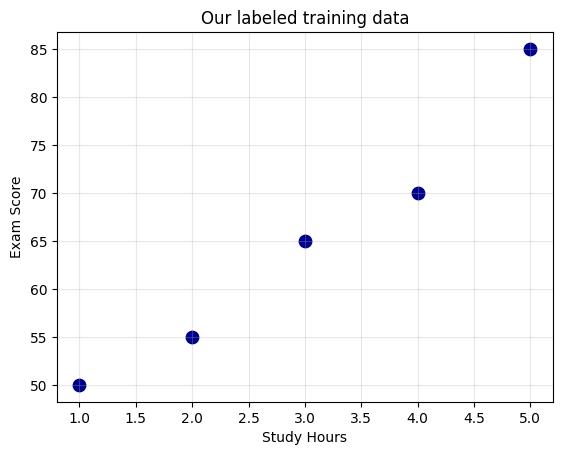

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Our tiny labeled dataset: (study hours -> exam score)
hours  = np.array([1, 2, 3, 4, 5], dtype=float)
scores = np.array([50, 55, 65, 70, 85], dtype=float)

plt.scatter(hours, scores, color="darkblue", s=80)
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Our labeled training data")
plt.grid(alpha=0.3)
plt.show()

## Step 1: The Model (a straight line)

We're predicting: `score = weight * hours + bias`

This is called **linear regression**. `weight` and `bias` start off random/zero and gradient descent will improve them.

In [2]:
def predict(hours, weight, bias):
    return weight * hours + bias

# Try a bad initial guess just to see how wrong it is
weight, bias = 0.0, 0.0
print("Predictions with weight=0, bias=0:", predict(hours, weight, bias))
print("Actual scores:                     ", scores)

Predictions with weight=0, bias=0: [0. 0. 0. 0. 0.]
Actual scores:                      [50. 55. 65. 70. 85.]


## Step 2: The Loss Function (how wrong are we?)

We use **Mean Squared Error (MSE)** — average of the squared differences between predictions and actual answers. Squaring makes all errors positive and punishes big mistakes more than small ones.

```
MSE = (1/n) * sum( (prediction - actual)^2 )
```

In [3]:
def mse_loss(hours, scores, weight, bias):
    predictions = predict(hours, weight, bias)
    return np.mean((predictions - scores) ** 2)

print("Loss with weight=0, bias=0:", mse_loss(hours, scores, weight, bias))

Loss with weight=0, bias=0: 4375.0


## Step 3: The Gradient (which way is downhill?)

We need the slope of the loss with respect to `weight` and with respect to `bias`. Using calculus (chain rule) on the MSE formula gives us:

```
gradient_weight = (2/n) * sum( (prediction - actual) * hours )
gradient_bias   = (2/n) * sum( (prediction - actual) )
```

You don't need to derive this by hand to use it — just notice it's built directly from the *error* (`prediction - actual`), same idea as file `02_calculus_basics.md`.

In [4]:
def compute_gradients(hours, scores, weight, bias):
    n = len(hours)
    predictions = predict(hours, weight, bias)
    error = predictions - scores

    grad_weight = (2 / n) * np.sum(error * hours)
    grad_bias   = (2 / n) * np.sum(error)
    return grad_weight, grad_bias

gw, gb = compute_gradients(hours, scores, weight, bias)
print(f"Gradient w.r.t weight: {gw:.2f}")
print(f"Gradient w.r.t bias:   {gb:.2f}")

Gradient w.r.t weight: -424.00
Gradient w.r.t bias:   -130.00


## Step 4: Gradient Descent Loop

Now the star of the show. Each step:

```
weight = weight - learning_rate * gradient_weight
bias   = bias   - learning_rate * gradient_bias
```

We repeat this many times ("epochs") and watch the loss shrink.

In [5]:
# Hyperparameters (settings we choose)
learning_rate = 0.02
epochs = 1000

# Start from scratch
weight, bias = 0.0, 0.0
loss_history = []

for epoch in range(epochs):
    grad_weight, grad_bias = compute_gradients(hours, scores, weight, bias)

    # <-- THIS is gradient descent -->
    weight = weight - learning_rate * grad_weight
    bias   = bias   - learning_rate * grad_bias

    loss = mse_loss(hours, scores, weight, bias)
    loss_history.append(loss)

    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss:8.3f} | weight: {weight:.3f} | bias: {bias:.3f}")

print("\nFinal learned equation:")
print(f"score = {weight:.2f} * hours + {bias:.2f}")

Epoch    0 | Loss: 1371.542 | weight: 8.480 | bias: 2.600
Epoch  100 | Loss:   60.518 | weight: 13.316 | bias: 22.114
Epoch  200 | Loss:   19.664 | weight: 10.943 | bias: 30.679
Epoch  300 | Loss:    9.146 | weight: 9.740 | bias: 35.024
Epoch  400 | Loss:    6.439 | weight: 9.129 | bias: 37.229
Epoch  500 | Loss:    5.742 | weight: 8.819 | bias: 38.348
Epoch  600 | Loss:    5.562 | weight: 8.662 | bias: 38.915
Epoch  700 | Loss:    5.516 | weight: 8.582 | bias: 39.203
Epoch  800 | Loss:    5.504 | weight: 8.542 | bias: 39.349
Epoch  900 | Loss:    5.501 | weight: 8.521 | bias: 39.424

Final learned equation:
score = 8.51 * hours + 39.46


## Step 5: Visualize Learning

Two plots:
1. **Loss curve** — should smoothly go downhill (just like our hiker!)
2. **Fitted line** — the model's straight line drawn over the real data points

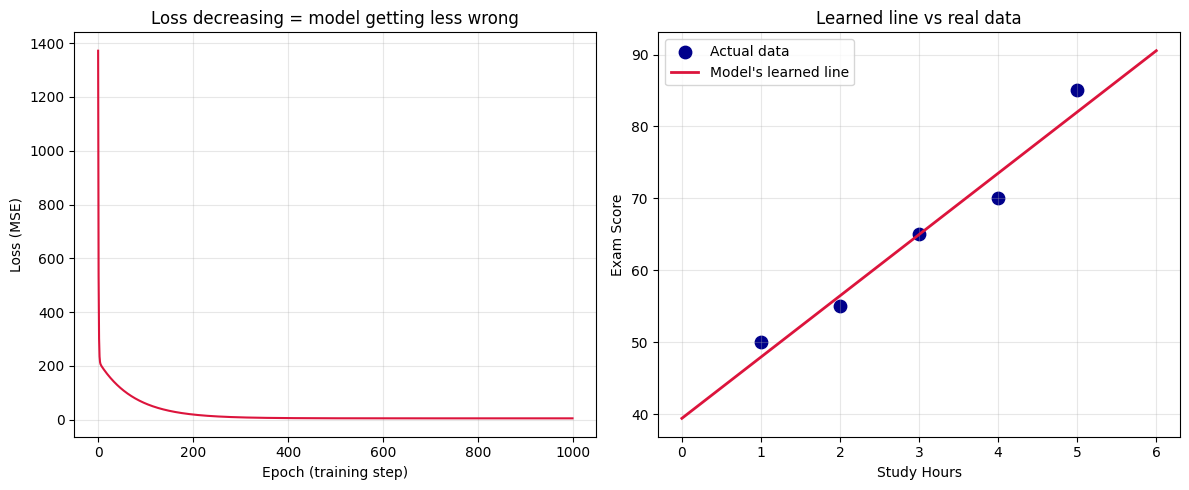

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Loss going down over time
axes[0].plot(loss_history, color="crimson")
axes[0].set_xlabel("Epoch (training step)")
axes[0].set_ylabel("Loss (MSE)")
axes[0].set_title("Loss decreasing = model getting less wrong")
axes[0].grid(alpha=0.3)

# Plot 2: Final fitted line vs actual data
axes[1].scatter(hours, scores, color="darkblue", s=80, label="Actual data")
line_x = np.linspace(0, 6, 100)
line_y = predict(line_x, weight, bias)
axes[1].plot(line_x, line_y, color="crimson", linewidth=2, label="Model's learned line")
axes[1].set_xlabel("Study Hours")
axes[1].set_ylabel("Exam Score")
axes[1].set_title("Learned line vs real data")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Step 6: Predict on New, Unseen Data

This is the whole point of supervised learning — use what was learned to predict answers for inputs it has **never seen**.

In [7]:
new_hours = np.array([6, 7, 0.5])
new_predictions = predict(new_hours, weight, bias)

for h, p in zip(new_hours, new_predictions):
    print(f"Studying {h} hours -> predicted exam score: {p:.1f}")

Studying 6.0 hours -> predicted exam score: 90.5
Studying 7.0 hours -> predicted exam score: 99.0
Studying 0.5 hours -> predicted exam score: 43.7


## 🔬 Try It Yourself

Things to experiment with (just change a value above and re-run):

- Set `learning_rate = 0.5` — what happens to the loss curve? (hint: it may explode — too big a step!)
- Set `learning_rate = 0.0001` — does it converge in 1000 epochs? (hint: probably too slow)
- Add more data points to `hours` / `scores` and see how the line adjusts
- Change `epochs` to `10` — does the model finish learning, or does it stop too early?

## ✅ What You Just Built

You implemented, from scratch:
- A **supervised learning model** (linear regression)
- A **loss function** (MSE) to measure wrongness
- A **gradient** calculation (the calculus from file `02`)
- The **gradient descent loop** (the algorithm from file `03`) that actually trains the model

This exact loop — predict, measure error, compute gradient, step downhill, repeat — is the beating heart of nearly every machine learning model in use today, from simple regression to giant neural networks.